# Notebook 03 - Product Embeddings, Customer Vectors and Clustering

This notebook builds product embeddings from baskets, aggregates them into product-led customer vectors, reduces dimensionality, compares clustering candidates, and profiles the resulting customer tribes.

## Table of Contents
- [3.0 Setup and Run Controls](#30-setup-and-run-controls)
- [3.1 Product Embedding Pipeline](#31-product-embedding-pipeline)
- [3.2 Customer Vector Construction](#32-customer-vector-construction)
- [3.3 Dimensionality Reduction](#33-dimensionality-reduction)
- [3.4 Clustering Experiments](#34-clustering-experiments)
- [3.5 Tribe Profiling](#35-tribe-profiling)
- [3.6 Final Customer Tribe Outputs](#36-final-customer-tribe-outputs)

<a id="30-setup-and-run-controls"></a>
## 3.0 Setup and Run Controls

Select mode, import dependencies, validate upstream artifacts from Notebook 02, and configure rerun controls for UMAP and clustering.

In [1]:
# -- Mode selector -- change this before running the notebook ----------------
# "dev"  -> data/dev/df_combined.parquet  (~44k customers, fast iteration)
# "prod" -> data/processed/df_combined.parquet  (1.48M customers, final run)

import os, sys, importlib
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

os.environ["CARREFOUR_MODE"] = "dev"   # <-- change to "prod" for final run

import src.config
importlib.reload(src.config)

from src.config import MODE, DATA_PROCESSED, MODELS, OUTPUTS
print(f"Running in {MODE.upper()} mode")
print(f"  Data   : {DATA_PROCESSED}")
print(f"  Models : {MODELS}")
print(f"  Outputs: {OUTPUTS}")

Running in DEV mode
  Data   : C:\Users\sebog\proyectos\carrefour_capstone\data\dev
  Models : C:\Users\sebog\proyectos\carrefour_capstone\models\dev
  Outputs: C:\Users\sebog\proyectos\carrefour_capstone\outputs\dev


In [2]:
import sys, warnings, logging, time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.config import ROOT, MODE, DATA_PROCESSED, OUTPUTS

OUTPUTS.mkdir(parents=True, exist_ok=True)

# -- Confirm Notebook 2 outputs exist before proceeding ----------------------
# quality_report.json and customer_kpis.parquet are prod-only artifacts
# (always in data/processed/). df_combined.parquet is mode-specific:
# data/dev/ in dev mode, data/processed/ in prod mode.
PROD_PROCESSED = ROOT / "data" / "processed"

required = {
    DATA_PROCESSED / "df_combined.parquet"  : "Section 3 (02_pre-analysis.ipynb)",
    PROD_PROCESSED / "customer_kpis.parquet": "Section 4.1 (02_pre-analysis.ipynb)",
    PROD_PROCESSED / "quality_report.json"  : "Section 2 (02_pre-analysis.ipynb)",
}
all_ok = True
for fpath, source in required.items():
    if fpath.exists():
        size = fpath.stat().st_size
        unit = "GB" if size > 1e9 else "MB"
        size_disp = size / (1024**3 if unit == "GB" else 1024**2)
        print(f"  OK  {fpath.name} ({size_disp:.1f} {unit})  [{fpath.parent.name}/]")
    else:
        print(f"  MISSING  {fpath}  <- run {source} first")
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "One or more Notebook 2 outputs are missing. "
        "Run 02_pre-analysis.ipynb in prod mode first."
    )

print(f"\nAll outputs confirmed. Running in {MODE.upper()} mode — ready to proceed.")

  OK  df_combined.parquet (85.3 MB)  [dev/]
  OK  customer_kpis.parquet (121.4 MB)  [processed/]
  OK  quality_report.json (0.0 MB)  [processed/]

All outputs confirmed. Running in DEV mode — ready to proceed.


<a id="31-product-embedding-pipeline"></a>
## 3.1 Product Embedding Pipeline

Build Item2Vec product embeddings from basket co-occurrence. These embeddings represent products by the company they keep in real customer baskets.

In [3]:
# ── Section 5 entry point — safe to run even if Sections 1–3 were skipped ─────
import sys, logging
from pathlib import Path

# Locate project root regardless of where Jupyter was launched from
_root = next(
    p for p in [Path.cwd(), Path.cwd().parent]
    if (p / "src" / "config.py").exists()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

from src.embeddings import (
    build_basket_sentences,
    train_word2vec,
    save_embeddings,
    sanity_check,
)
from src.config import DATA_PROCESSED, MODELS

# Re-attach df_articles if this session skipped the earlier sections
if "df_articles" not in vars():
    from src.data_loader import load_maestra_articulos
    df_articles = load_maestra_articulos()
    print(f"Loaded df_articles: {len(df_articles):,} rows")
else:
    print(f"df_articles already in session: {len(df_articles):,} rows")

print("Section 5 imports OK")

Loaded df_articles: 893,944 rows
Section 5 imports OK


### 3.1.1 Build Basket Sentences

Convert each ticket into a product sequence so Word2Vec can learn product context from co-purchases.

20:51:53 INFO Building basket sentences from df_combined.parquet ...
20:51:54 INFO Saved 703,773 baskets → basket_sentences.parquet  (22 MB on disk)


Baskets built           :      703,773
Median items per basket :    7.0
Mean items per basket   :   10.5
p25 / p75               : 4 / 13
p99 (large baskets)     : 54
Single-item baskets     : 0.0%


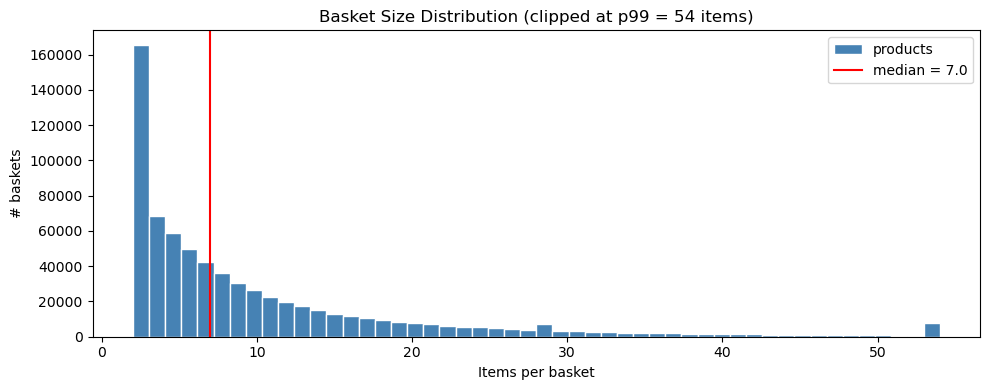

In [4]:
# 5.1 Build basket sentences
basket_path = build_basket_sentences()   # cached after first run
baskets = pl.read_parquet(basket_path)   # load into memory for stats

# Basket size distribution
basket_sizes = baskets["products"].list.len()   # Polars Series of ints

p99_size = int(basket_sizes.quantile(0.99))

size_stats = {
    "n_baskets":       len(baskets),
    "median_size":     float(basket_sizes.median()),
    "mean_size":       float(basket_sizes.mean()),
    "p25":             float(basket_sizes.quantile(0.25)),
    "p75":             float(basket_sizes.quantile(0.75)),
    "p99":             float(p99_size),
    "single_item_pct": float((basket_sizes == 1).mean() * 100),
}

print(f"Baskets built           : {size_stats['n_baskets']:>12,}")
print(f"Median items per basket : {size_stats['median_size']:>6.1f}")
print(f"Mean items per basket   : {size_stats['mean_size']:>6.1f}")
print(f"p25 / p75               : {size_stats['p25']:.0f} / {size_stats['p75']:.0f}")
print(f"p99 (large baskets)     : {size_stats['p99']:.0f}")
print(f"Single-item baskets     : {size_stats['single_item_pct']:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
# Polars clip uses upper_bound= (not upper= like pandas)
(
    basket_sizes
    .clip(upper_bound=p99_size)
    .to_pandas()
    .plot.hist(bins=50, ax=ax, color="steelblue", edgecolor="white",
               title=f"Basket Size Distribution (clipped at p99 = {p99_size} items)")
)
ax.set_xlabel("Items per basket")
ax.set_ylabel("# baskets")
ax.axvline(size_stats["median_size"], color="red", lw=1.5,
           label=f"median = {size_stats['median_size']:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "embedding_basket_sizes.png", dpi=120)
plt.show()

del baskets, basket_sizes   # free RAM before training

### 3.1.2 Train Product Word2Vec

Train product embeddings from basket sentences using the configured Word2Vec hyperparameters.

In [5]:
# 5.2 Train Word2Vec
# CBOW (sg=0) + 5 epochs: expected runtime ~20-40 min on first run
import time
_t0 = time.time()

w2v_model = train_word2vec(workers=4)

_elapsed = time.time() - _t0
print(f"\nTraining complete in {_elapsed/60:.1f} min")
print(f"Vocabulary size : {len(w2v_model.wv):,} products")
print(f"Vector size     : {w2v_model.wv.vector_size}")

20:51:55 INFO Loading cached model from word2vec_product.model ...
20:51:55 INFO loading Word2Vec object from C:\Users\sebog\proyectos\carrefour_capstone\models\dev\word2vec_product.model
20:51:55 INFO loading wv recursively from C:\Users\sebog\proyectos\carrefour_capstone\models\dev\word2vec_product.model.wv.* with mmap=None
20:51:55 INFO setting ignored attribute cum_table to None
20:51:55 INFO Word2Vec lifecycle event {'fname': 'C:\\Users\\sebog\\proyectos\\carrefour_capstone\\models\\dev\\word2vec_product.model', 'datetime': '2026-06-07T20:51:55.591273', 'gensim': '4.4.0', 'python': '3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'loaded'}



Training complete in 0.0 min
Vocabulary size : 56,356 products
Vector size     : 100


### 3.1.3 Save Embeddings and Coverage Check

Persist product vectors and confirm how much of the transaction product universe is covered by the embedding vocabulary.

In [6]:
# 5.3 Save embeddings & coverage check
product_embeddings = save_embeddings(w2v_model)

# Three populations to distinguish:
#   catalogue     = all products in the master table (many never purchased)
#   transacted    = products that appear in at least 1 basket in df_combined
#   with_embedding = products with >= min_count baskets got a Word2Vec vector
n_catalogue      = df_articles["idarticu"].n_unique()
n_transacted     = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .select(pl.col("products").n_unique())
    .collect(engine="streaming")
    .item()
)
n_with_embedding = len(product_embeddings)
n_below_min      = n_transacted - n_with_embedding
n_never_bought   = n_catalogue - n_transacted

print("=" * 58)
print("  PRODUCT EMBEDDING COVERAGE")
print("=" * 58)
print(f"  Full catalogue (master table)   : {n_catalogue:>10,}")
print(f"  Never purchased in 6 months     : {n_never_bought:>10,}  "
      f"({n_never_bought/n_catalogue*100:.1f}% of catalogue not in transactions at all)")
print(f"  Ever purchased (basket)      : {n_transacted:>10,}")
print(f"    Below min_count (<3 baskets)  : {n_below_min:>10,}  "
      f"({n_below_min/n_transacted*100:.1f}% of purchased too rare to embed)")
print(f"    With embedding  (baskets)  : {n_with_embedding:>10,}  "
      f"({n_with_embedding/n_transacted*100:.1f}% of purchased)")
print("=" * 58)
print(f"\n  Effective Phase 2 coverage: {n_with_embedding/n_transacted*100:.1f}% of purchased products")
print(f"  Products below min_count will fall back to their sector centroid in Phase 2.")
print(f"\n  Embedding shape : {n_with_embedding:,} products — {w2v_model.wv.vector_size} dims")
print(f"  File size       : {(DATA_PROCESSED / 'product_embeddings.parquet').stat().st_size / 1024**2:.1f} MB")

20:51:56 INFO Saved 56,356 embeddings → product_embeddings.parquet  (20.1 MB on disk)


  PRODUCT EMBEDDING COVERAGE
  Full catalogue (master table)   :    893,944
  Never purchased in 6 months     :    817,342  (91.4% of catalogue not in transactions at all)
  Ever purchased (basket)      :     76,602
    Below min_count (<3 baskets)  :     20,246  (26.4% of purchased too rare to embed)
    With embedding  (baskets)  :     56,356  (73.6% of purchased)

  Effective Phase 2 coverage: 73.6% of purchased products
  Products below min_count will fall back to their sector centroid in Phase 2.

  Embedding shape : 56,356 products — 100 dims
  File size       : 20.1 MB


### 3.1.4 Product Embedding Sanity Check

Inspect nearest-neighbour products to confirm that the embedding space is commercially sensible.

In [7]:
# 5.4 Sanity check
# Auto-select the most-purchased product from 3 sectors as probes.
# Explode basket_sentences to get per-product basket counts (small file, safe to collect).
_embedded_set = set(product_embeddings["idarticu"].to_list())

_pop = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .rename({"products": "idarticu"})
    .group_by("idarticu")
    .agg(pl.len().alias("n_baskets"))
    .collect(engine="streaming")   # basket parquet is ~20M rows stream to be safe
    .filter(pl.col("idarticu").is_in(list(_embedded_set)))
    .join(
        df_articles.select(["idarticu", "desc_larga_articulo", "desc_sector"]),
        on="idarticu", how="left",
    )
    .sort("n_baskets", descending=True)
)

# Pick most popular embedded product from each target sector
_target_sectors = ["P.G.C.", "PROD. FRESCOS TRADIC", "BAZAR"]
probe_ids = []
for sector in _target_sectors:
    row = _pop.filter(pl.col("desc_sector") == sector).head(1)
    if len(row) > 0:
        pid  = int(row["idarticu"][0])
        name = row["desc_larga_articulo"][0]
        nb   = int(row["n_baskets"][0])
        probe_ids.append(pid)
        print(f"Probe [{sector}]: {name[:50]}  (in {nb:,} baskets)")

print()
sanity_check(w2v_model, df_articles, probe_ids, topn=7)

Probe [P.G.C.]: PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G  (in 9,267 baskets)
Probe [PROD. FRESCOS TRADIC]: BANANA GRANEL  (in 50,467 baskets)
Probe [BAZAR]: BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFOUR  (in 160,758 baskets)


  PROBE  [P.G.C.]
  PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G
  idarticu = 443145
     Score  Sector                      Product
  --------  --------------------------  ----------------------------------
    0.7775  P.G.C.                      PAN MOLDE BLANCO CON CORTEZA CARRE
    0.7365  PROD. FRESCOS TRADIC        MORTADELA CARREFOUR LONCHAS 250 G
    0.7312  PROD. FRESCOS TRADIC        MORTADELA DE PAVO LONCHAS TP NUEVA
    0.7308  P.G.C.                      ZUMOS DE PIÃA-UVA CONCENTRADO ZUM
    0.7284  P.G.C.                      YOGUR SABORES CARREFOUR 16X125G
    0.7263  PROD. FRESCOS TRADIC        CHOPPED PORK LONCHAS TP NUEVA RECE
    0.7255  PROD. FRESCOS TRADIC        BACON AHUMADO SIN FECULA SIN CORTE

  PROBE  [PROD. FRESCOS TRADIC]
  BAN

### 3.1.5 Product Embedding Summary

Summarize the product representation built in this phase and its role in customer vector construction.

<a id="32-customer-vector-construction"></a>
## 3.2 Customer Vector Construction

Aggregate purchased product embeddings into one product-led vector per customer. Frequency and recency weighting make repeated and recent purchases more influential.

In [8]:
# Notebook 3 entry point Phases 2 to 4 
import sys, time, warnings, logging
from pathlib import Path

# Locate project root regardless of where Jupyter was launched from
_root = next(
    p for p in [Path.cwd(), Path.cwd().parent]
    if (p / "src" / "config.py").exists()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

warnings.filterwarnings("ignore")
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from src.config import (
    DATA_PROCESSED,
    FEATURE_WEIGHT_KPI,
    FEATURE_WEIGHT_PROMO,
    FEATURE_WEIGHT_STORE,
    KMEANS_BASELINE_CLUSTERS,
    MODELS,
    OUTPUTS,
    RECENCY_HALFLIFE_DAYS,
)
from src.customer_vectors import (
    _build_interactions,
    build_customer_vectors,
    build_customer_vectors_mean,
)
from src.dimensionality import reduce_umap_cluster, reduce_umap_viz, reduce_pca
from src.clustering import (
    cluster_hdbscan,
    cluster_kmeans,
    evaluate_clustering,
    grid_search_hdbscan,
    profile_tribes,
    run_kmeans_baselines,
)

OUTPUTS.mkdir(parents=True, exist_ok=True)

# Run controls. Keep True for the first run after changing UMAP/clustering config;
# set to False afterward to reuse caches.
FORCE_PRODUCT_LED_UMAP = True
FORCE_CLUSTERING = True
TARGET_KMEANS_K = 15

# Confirm Phase 1 outputs exist before proceeding
required = {
    "df_combined.parquet"        : "Section 3 (Notebook 1)",
    "product_embeddings.parquet" : "Section 5 (Notebook 3)",
}
for fname, source in required.items():
    path = DATA_PROCESSED / fname
    if path.exists():
        print(f"{fname}: OK ({path.stat().st_size / 1024**2:.0f} MB)")
    else:
        raise FileNotFoundError(f"{fname} not found - run {source} first")

print("Ready to proceed to Section 6")
print(
    "Feature weights for UMAP:",
    f"product vectors=1.0, promo={FEATURE_WEIGHT_PROMO}, store={FEATURE_WEIGHT_STORE}, KPI={FEATURE_WEIGHT_KPI}",
)
print(f"K-Means baseline K values: {KMEANS_BASELINE_CLUSTERS}; selected K={TARGET_KMEANS_K}")

df_combined.parquet: OK (85 MB)
product_embeddings.parquet: OK (20 MB)
Ready to proceed to Section 6
Feature weights for UMAP: product vectors=1.0, promo=1.0, store=1.0, KPI=0.0
K-Means baseline K values: [8, 12, 15, 18]; selected K=15


### 3.2.1 Interaction Weights

Compute per-customer, per-product purchase weights from transaction frequency and recency.

In [9]:
# First run streams 190M rows — expect 10–20 min. Subsequent runs: cache hit.
_t0 = time.time()

interactions = _build_interactions(
    DATA_PROCESSED / "df_combined.parquet",
    halflife_days=RECENCY_HALFLIFE_DAYS,
)

_elapsed = time.time() - _t0
print(f"Stage 1 complete in {_elapsed/60:.1f} min")
print(f"Shape    : {interactions.shape[0]:,} rows × {interactions.shape[1]} cols")

pairs_per_cust = (
    interactions.group_by("cliente")
    .agg(pl.len().alias("n_products"))
    ["n_products"]
)
print(f"\nUnique customers : {interactions['cliente'].n_unique():,}")
print(f"Unique products  : {interactions['idarticu'].n_unique():,}")
print(f"\nUnique products per customer:")
print(f"  median : {pairs_per_cust.median():.0f}")
print(f"  mean   : {pairs_per_cust.mean():.0f}")
print(f"  p75    : {pairs_per_cust.quantile(0.75):.0f}")
print(f"  p95    : {pairs_per_cust.quantile(0.95):.0f}")
print(f"  max    : {pairs_per_cust.max():,}")

20:52:05 INFO Stage 1 — streaming df_combined → interaction weights (halflife=60 d, λ=0.0116, reference=2022-06-30) ...
20:52:07 INFO Saved 4,748,184 (customer, product) pairs → customer_product_weights.parquet  (27 MB on disk)


Stage 1 complete in 0.0 min
Shape    : 4,748,184 rows × 5 cols

Unique customers : 44,000
Unique products  : 77,777

Unique products per customer:
  median : 73
  mean   : 108
  p75    : 146
  p95    : 322
  max    : 1,712


### 3.2.2 Weighted Customer Vectors

Build the primary customer vectors from frequency- and recency-weighted product embeddings.

In [10]:
_t0 = time.time()

cv_weighted = build_customer_vectors()   # cached after first run

_elapsed = time.time() - _t0
print(f"Weighted vectors built in {_elapsed/60:.1f} min")
print(f"Shape   : {cv_weighted.shape[0]:,} customers × {len(cv_weighted['vector'][0])} dims")
print(f"Schema  : {cv_weighted.schema}")

n_total_cust = interactions["cliente"].n_unique()
n_vectorised = len(cv_weighted)
print(f"\nCoverage:")
print(f"  With ≥1 embedded product : {n_vectorised:>10,}  ({n_vectorised/n_total_cust*100:.1f}%)")
print(f"  No embedded product      : {n_total_cust-n_vectorised:>10,}  ({(n_total_cust-n_vectorised)/n_total_cust*100:.1f}%)  ← only bought rare products")

print(f"\nPromo rate distribution:")
print(f"  mean   : {cv_weighted['promo_rate'].mean():.3f}")
print(f"  median : {cv_weighted['promo_rate'].median():.3f}")
print(f"  p25    : {cv_weighted['promo_rate'].quantile(0.25):.3f}")
print(f"  p75    : {cv_weighted['promo_rate'].quantile(0.75):.3f}")

20:52:07 INFO Interactions cache hit — 4,748,184 (customer, product) pairs


20:52:08 INFO   Pairs with embeddings: 4,703,614 / 4,748,184  (44,000 unique customers covered)
20:52:08 INFO Stage 2 — sparse @ dense  (44,000 × 56,356) @ (56,356 × 100) ...
20:52:09 INFO   Done — 44,000 customer vectors computed
20:52:10 INFO Saved 44,000 weighted customer vectors → customer_vectors_weighted.parquet  (17.1 MB on disk)


Weighted vectors built in 0.0 min
Shape   : 44,000 customers × 100 dims
Schema  : Schema([('cliente', String), ('vector', List(Float32)), ('promo_rate', Float32)])

Coverage:
  With ≥1 embedded product :     44,000  (100.0%)
  No embedded product      :          0  (0.0%)  ← only bought rare products

Promo rate distribution:
  mean   : 0.225
  median : 0.208
  p25    : 0.150
  p75    : 0.276


### 3.2.3 Mean Customer Vectors Baseline

Build an unweighted mean-vector baseline for comparison against the weighted representation.

In [11]:
_t0 = time.time()

cv_mean = build_customer_vectors_mean()   # reuses Stage 1 cache — only Stage 2 differs

_elapsed = time.time() - _t0
print(f"Mean vectors built in {_elapsed/60:.1f} min")
print(f"Shape : {cv_mean.shape[0]:,} customers × {len(cv_mean['vector'][0])} dims")
print(f"File  : {(DATA_PROCESSED / 'customer_vectors_mean.parquet').stat().st_size / 1024**2:.1f} MB on disk")

20:52:10 INFO Interactions cache hit — 4,748,184 (customer, product) pairs
20:52:10 INFO   Pairs with embeddings: 4,703,614 / 4,748,184  (44,000 unique customers covered)
20:52:11 INFO Stage 2 — sparse @ dense  (44,000 × 56,356) @ (56,356 × 100) ...
20:52:11 INFO   Done — 44,000 customer vectors computed
20:52:12 INFO Saved 44,000 mean customer vectors → customer_vectors_mean.parquet  (17.1 MB on disk)


Mean vectors built in 0.0 min
Shape : 44,000 customers × 100 dims
File  : 17.1 MB on disk


### 3.2.4 Weighted vs Mean Vector Comparison

Quantify how much frequency and recency weighting changes customer vectors.

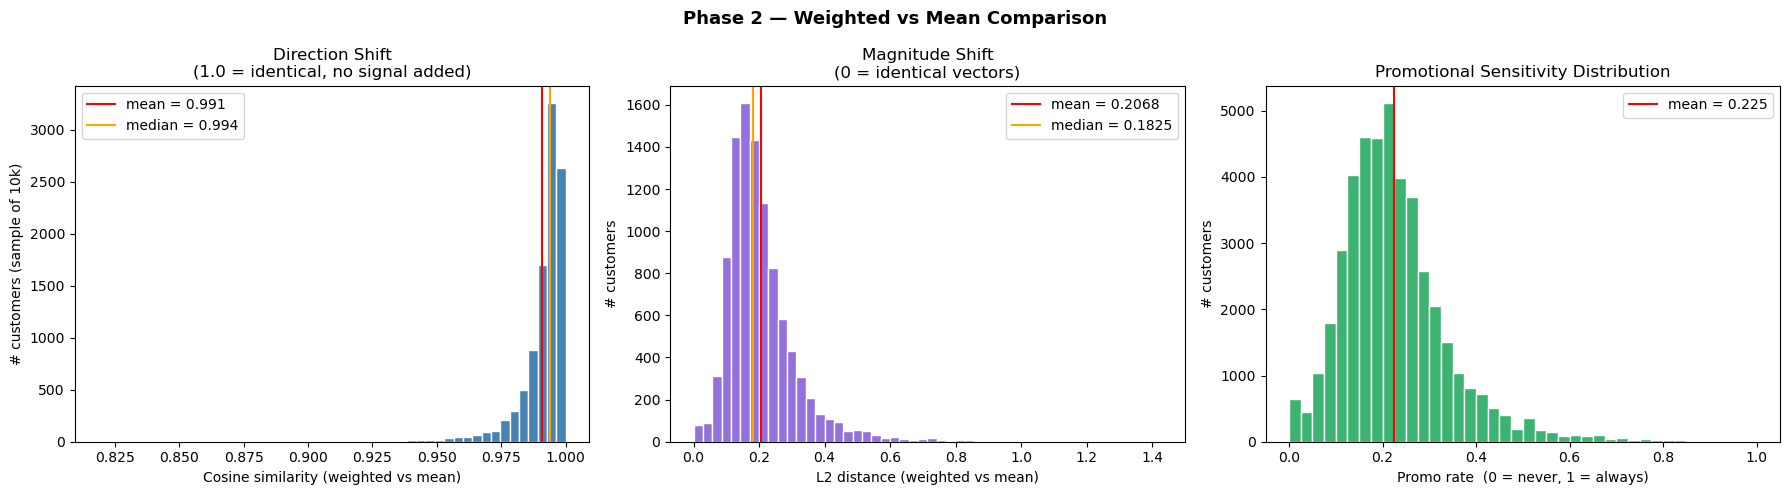

Cosine similarity:
  mean   : 0.9908
  median : 0.9939
  p25/p75: 0.9894 / 0.9965
  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.

L2 distance:
  mean   : 0.206807
  median : 0.182469

Promo sensitivity:
  Pure loyalists (0% promo)  : 1.4% of customers
  Promo surfers (>50% promo) : 2.6% of customers


In [12]:
# Sample 10k customers present in both outputs
_common = cv_weighted.join(
    cv_mean.select(["cliente", "vector"]).rename({"vector": "vector_mean"}),
    on="cliente", how="inner",
).sample(n=min(10_000, len(cv_weighted)), seed=42)

_v_w = np.array(_common["vector"].to_list(),      dtype=np.float32)
_v_m = np.array(_common["vector_mean"].to_list(), dtype=np.float32)

# Row-wise cosine similarity
_cos_sim = (
    (_v_w * _v_m).sum(axis=1)
    / (np.linalg.norm(_v_w, axis=1) * np.linalg.norm(_v_m, axis=1) + 1e-9)
)

# Row-wise L2 distance
_l2_dist = np.linalg.norm(_v_w - _v_m, axis=1)

_promo = cv_weighted["promo_rate"].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(_cos_sim, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(_cos_sim.mean(),     color="red",    lw=1.5, label=f"mean = {_cos_sim.mean():.3f}")
axes[0].axvline(np.median(_cos_sim), color="orange", lw=1.5, label=f"median = {np.median(_cos_sim):.3f}")
axes[0].set_xlabel("Cosine similarity (weighted vs mean)")
axes[0].set_ylabel("# customers (sample of 10k)")
axes[0].set_title("Direction Shift\n(1.0 = identical, no signal added)")
axes[0].legend()

axes[1].hist(_l2_dist, bins=50, color="mediumpurple", edgecolor="white")
axes[1].axvline(_l2_dist.mean(),     color="red",    lw=1.5, label=f"mean = {_l2_dist.mean():.4f}")
axes[1].axvline(np.median(_l2_dist), color="orange", lw=1.5, label=f"median = {np.median(_l2_dist):.4f}")
axes[1].set_xlabel("L2 distance (weighted vs mean)")
axes[1].set_ylabel("# customers")
axes[1].set_title("Magnitude Shift\n(0 = identical vectors)")
axes[1].legend()

axes[2].hist(_promo, bins=40, color="mediumseagreen", edgecolor="white")
axes[2].axvline(_promo.mean(), color="red", lw=1.5, label=f"mean = {_promo.mean():.3f}")
axes[2].set_xlabel("Promo rate  (0 = never, 1 = always)")
axes[2].set_ylabel("# customers")
axes[2].set_title("Promotional Sensitivity Distribution")
axes[2].legend()

plt.suptitle("Phase 2 — Weighted vs Mean Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase2_vector_comparison.png", dpi=120)
plt.show()

never_promo = (_promo == 0).mean() * 100
high_promo  = (_promo > 0.5).mean() * 100

print(f"Cosine similarity:")
print(f"  mean   : {_cos_sim.mean():.4f}")
print(f"  median : {np.median(_cos_sim):.4f}")
print(f"  p25/p75: {np.percentile(_cos_sim,25):.4f} / {np.percentile(_cos_sim,75):.4f}")
print(f"  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.")
print(f"\nL2 distance:")
print(f"  mean   : {_l2_dist.mean():.6f}")
print(f"  median : {np.median(_l2_dist):.6f}")
print(f"\nPromo sensitivity:")
print(f"  Pure loyalists (0% promo)  : {never_promo:.1f}% of customers")
print(f"  Promo surfers (>50% promo) : {high_promo:.1f}% of customers")

### 3.2.5 Customer Vector Summary

Connect customer vectors to the dimensionality-reduction and clustering steps that follow.

### 3.2.6 Store Affinity Features

Compute store-format spend shares for profiling and optional modeling context.

20:52:13 INFO Computing per-customer store spend shares from df_combined.parquet ...
20:52:13 INFO   Stores found: ['11', '2', '6', '7']
20:52:13 INFO Saved 44,000 customer store features → customer_store_features.parquet  (4 stores, 1.7 MB on disk)


Stores in data         : ['spend_share_s7', 'spend_share_s2', 'spend_share_s6', 'spend_share_s11']
Customers with store data: 44,000

Store reach (% of customers who spend anything at each store):
  spend_share_s7        :  78.1% shop there  |   62.4% spend >80% there
  spend_share_s2        :  40.4% shop there  |   18.3% spend >80% there
  spend_share_s6        :  23.1% shop there  |    5.4% spend >80% there
  spend_share_s11       :   2.5% shop there  |    0.1% spend >80% there

Cross-store shopping behaviour:
  Single-store loyalists (only 1 store) : 62.1%
  2-store shoppers                      : 31.9%
  3+ store shoppers                     : 6.0%


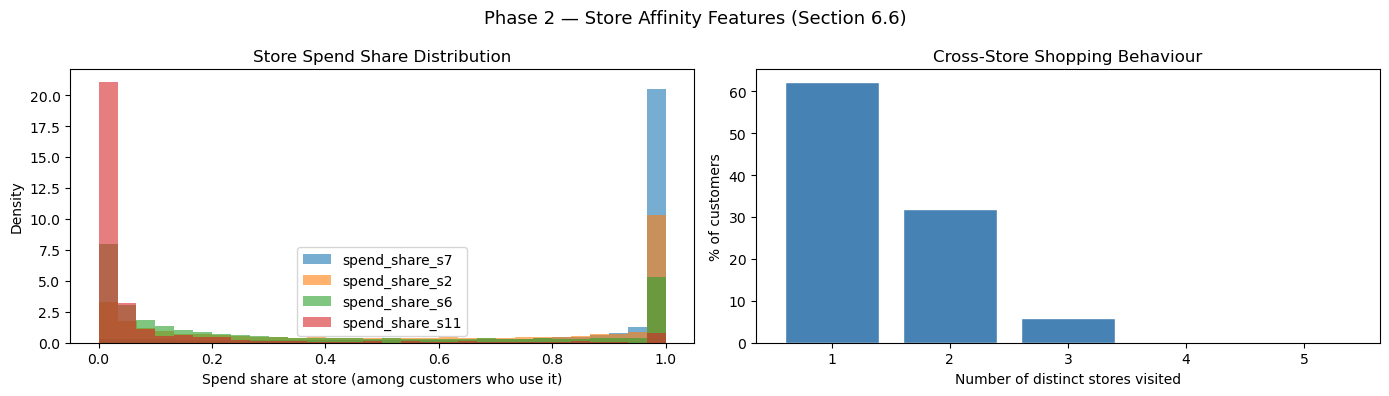


→ Store spend shares will be appended to UMAP input in Section 7.
→ This ensures tribes are not confounded by store-format access constraints.


In [13]:
# 6.6 Store affinity features
from src.customer_vectors import build_store_features

store_feats = build_store_features()   # cached after first run

store_cols = [c for c in store_feats.columns if c != "cliente"]
store_arr  = store_feats.select(store_cols).to_numpy()
n_stores_active = (store_arr > 0).sum(axis=1)   # how many stores each customer uses

print(f"Stores in data         : {store_cols}")
print(f"Customers with store data: {len(store_feats):,}")
print()

print("Store reach (% of customers who spend anything at each store):")
for col in store_cols:
    pct_any      = (store_feats[col] > 0).mean() * 100
    pct_dominant = (store_feats[col] > 0.8).mean() * 100
    print(f"  {col:<22}: {pct_any:5.1f}% shop there  |  {pct_dominant:5.1f}% spend >80% there")

print()
print("Cross-store shopping behaviour:")
print(f"  Single-store loyalists (only 1 store) : {(n_stores_active == 1).mean()*100:.1f}%")
print(f"  2-store shoppers                      : {(n_stores_active == 2).mean()*100:.1f}%")
print(f"  3+ store shoppers                     : {(n_stores_active >= 3).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Store spend share distributions
for col in store_cols:
    vals = store_feats.filter(pl.col(col) > 0)[col].to_numpy()
    axes[0].hist(vals, bins=30, alpha=0.6, label=col, density=True)
axes[0].set_xlabel("Spend share at store (among customers who use it)")
axes[0].set_ylabel("Density")
axes[0].set_title("Store Spend Share Distribution")
axes[0].legend()

# Cross-store shopping
axes[1].bar(range(1, len(store_cols)+2),
            [(n_stores_active == k).mean()*100 for k in range(1, len(store_cols)+2)],
            color="steelblue", edgecolor="white")
axes[1].set_xlabel("Number of distinct stores visited")
axes[1].set_ylabel("% of customers")
axes[1].set_title("Cross-Store Shopping Behaviour")

plt.suptitle("Phase 2 — Store Affinity Features (Section 6.6)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "phase2_store_affinity.png", dpi=120)
plt.show()

print()
print("→ Store spend shares will be appended to UMAP input in Section 7.")
print("→ This ensures tribes are not confounded by store-format access constraints.")

<a id="33-dimensionality-reduction"></a>
## 3.3 Dimensionality Reduction

Reduce high-dimensional customer vectors into spaces suitable for clustering and visualization.

### 3.3.1 UMAP Clustering Embedding

Create the primary product-led UMAP embedding used by clustering algorithms.

In [14]:
# Fit on 300k sample to transform all 1.48M
# FORCE_PRODUCT_LED_UMAP=True rebuilds the cache after changing feature weights.
_t0 = time.time()

umap_cluster = reduce_umap_cluster(cv_weighted, force=FORCE_PRODUCT_LED_UMAP)

_elapsed = time.time() - _t0
_umap_dim_count = len([c for c in umap_cluster.columns if c.startswith("u")])
print(f"UMAP {_umap_dim_count}D done in {_elapsed/60:.1f} min")
print(f"Shape   : {umap_cluster.shape[0]:,} customers x {_umap_dim_count} dims")
print(umap_cluster.head(3))

20:52:14 INFO   Promo feature appended (weight=1.00)
20:52:14 INFO   Store features appended: 4 columns (weight=1.00)
20:52:14 INFO   KPI features skipped (weight=0)
20:52:14 INFO UMAP cluster fit: 44,000 sample, input_dims=105, n_neighbors=50, n_components=50, metric=cosine ...
20:54:01 INFO UMAP fit complete. Transforming all 44,000 customers ...
20:54:02 INFO Saved 44,000 UMAP cluster embeddings → umap_cluster_20d.parquet  (8.2 MB on disk)


UMAP 50D done in 1.8 min
Shape   : 44,000 customers x 50 dims
shape: (3, 52)
┌──────────────┬──────────┬──────────┬───────────┬───┬──────────┬──────────┬──────────┬────────────┐
│ cliente      ┆ u0       ┆ u1       ┆ u2        ┆ … ┆ u47      ┆ u48      ┆ u49      ┆ promo_rate │
│ ---          ┆ ---      ┆ ---      ┆ ---       ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---        │
│ str          ┆ f32      ┆ f32      ┆ f32       ┆   ┆ f32      ┆ f32      ┆ f32      ┆ f32        │
╞══════════════╪══════════╪══════════╪═══════════╪═══╪══════════╪══════════╪══════════╪════════════╡
│ 00013178015a ┆ 0.724581 ┆ 2.234364 ┆ -0.543556 ┆ … ┆ 4.250309 ┆ 5.927077 ┆ 2.466053 ┆ 0.272152   │
│ dada491dee5b ┆          ┆          ┆           ┆   ┆          ┆          ┆          ┆            │
│ b3d793…      ┆          ┆          ┆           ┆   ┆          ┆          ┆          ┆            │
│ 0004c429304a ┆ 8.819345 ┆ 0.436793 ┆ 1.933493  ┆ … ┆ 4.308431 ┆ 5.853095 ┆ 2.478173 ┆ 0.087805   │
│ 68d786565cfb

### 3.3.2 PCA Baseline

Fit a linear baseline to compare against UMAP's non-linear structure preservation.

20:54:02 INFO PCA fit+transform on 44,000 × 100 ...
20:54:02 INFO PCA complete — 50 components explain 92.8% of variance
20:54:02 INFO Saved 44,000 PCA embeddings → pca_cluster_20d.parquet  (9.3 MB on disk)


PCA done in 0 s
Explained variance — 10 PCs: 72.0%  |  20 PCs: 82.1%


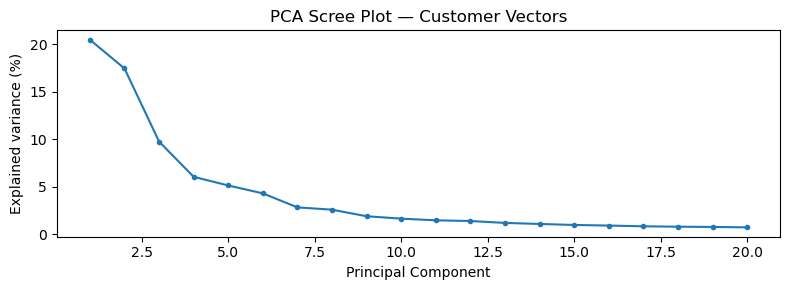

In [15]:
_t0 = time.time()

pca_cluster, pca_model = reduce_pca(cv_weighted)

_elapsed = time.time() - _t0
explained = pca_model.explained_variance_ratio_.cumsum()
print(f"PCA done in {_elapsed:.0f} s")
print(f"Explained variance — 10 PCs: {explained[9]:.1%}  |  20 PCs: {explained[19]:.1%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, 21), pca_model.explained_variance_ratio_[:20] * 100, marker="o", ms=3)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("PCA Scree Plot — Customer Vectors")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_pca_scree.png", dpi=120)
plt.show()

### 3.3.3 UMAP 2D Visualization Embedding

Project the clustering space to two dimensions for visual inspection and cluster maps.

20:54:02 INFO UMAP viz fit: 44,000 sample, n_components=2, min_dist=0.10 ...
20:54:40 INFO UMAP viz fit complete. Transforming all 44,000 customers ...
20:54:40 INFO Saved 44,000 UMAP viz embeddings → umap_viz_2d.parquet  (1.9 MB on disk)


UMAP 2D done in 0.6 min


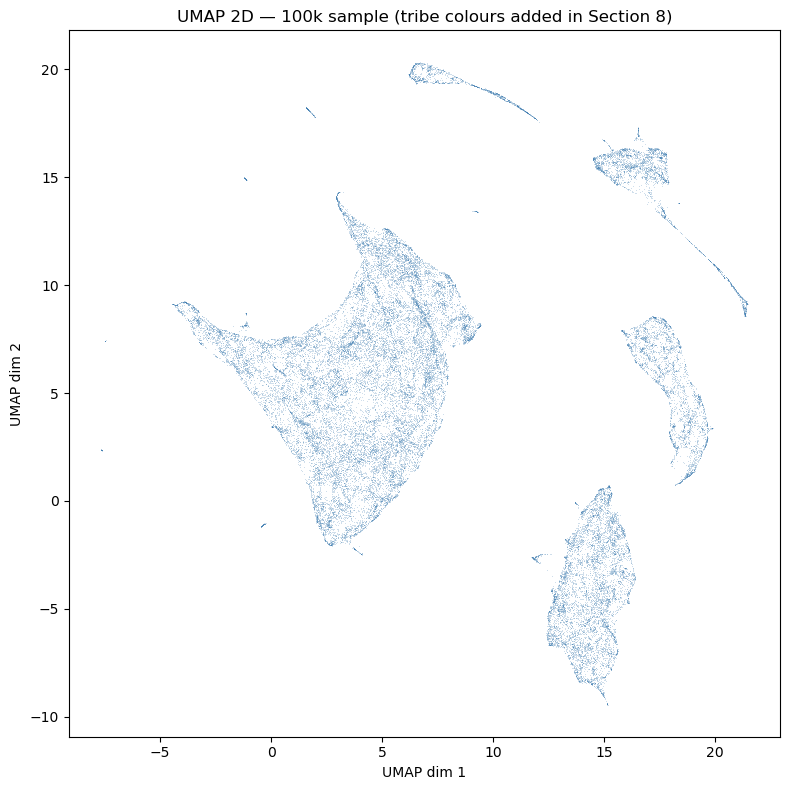

In [16]:
_t0 = time.time()

umap_viz = reduce_umap_viz(umap_cluster, force=FORCE_PRODUCT_LED_UMAP)   # derived from clustering UMAP, not raw vectors

_elapsed = time.time() - _t0
print(f"UMAP 2D done in {_elapsed/60:.1f} min")

# Preview scatter — no cluster colours yet, those come in Section 8
_sample = umap_viz.sample(n=min(100_000, len(umap_viz)), seed=42)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(_sample["x"].to_numpy(), _sample["y"].to_numpy(),
           s=0.3, alpha=0.3, c="steelblue", linewidths=0)
ax.set_title("UMAP 2D — 100k sample (tribe colours added in Section 8)")
ax.set_xlabel("UMAP dim 1"); ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_umap2d_preview.png", dpi=120)
plt.show()

### 3.3.4 UMAP Structure Preservation Check

Check whether the UMAP embeddings preserve nearest-neighbour structure from the original customer-vector space.

UMAP preservation check: 5,000 customers, k=30, original_metric=cosine
Original feature-space dims: 105 | UMAP dims: 50 -> 2
embedding trustworthiness knn_overlap
 UMAP 50D           0.952       0.275
  UMAP 2D           0.914       0.185


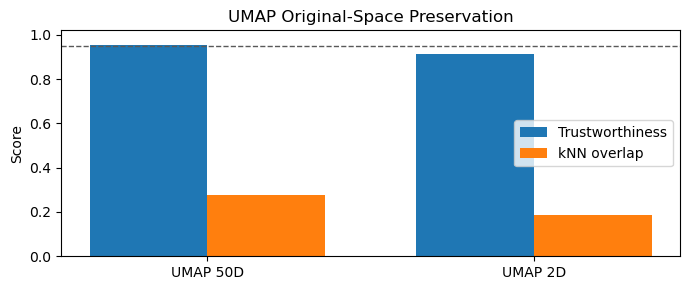

In [17]:
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from src.config import UMAP_METRIC

UMAP_EVAL_SAMPLE = min(5_000, len(cv_weighted))
UMAP_EVAL_K = 30

_umap_cols = [c for c in umap_cluster.columns if c.startswith("u")]
_eval = (
    cv_weighted.select(["cliente", "vector", "promo_rate"])
    .sample(n=UMAP_EVAL_SAMPLE, seed=42)
    .join(umap_cluster.select(["cliente"] + _umap_cols), on="cliente", how="inner")
    .join(umap_viz.select(["cliente", "x", "y"]), on="cliente", how="inner")
)

_X_parts = [np.array(_eval["vector"].to_list(), dtype=np.float32)]

if FEATURE_WEIGHT_PROMO > 0:
    _promo = _eval["promo_rate"].fill_null(0.0).to_numpy().reshape(-1, 1).astype(np.float32)
    _X_parts.append(_promo * FEATURE_WEIGHT_PROMO)

if FEATURE_WEIGHT_STORE > 0:
    _store_df = store_feats if "store_feats" in globals() else pl.read_parquet(DATA_PROCESSED / "customer_store_features.parquet")
    _store_cols = [c for c in _store_df.columns if c != "cliente"]
    _store_eval = (
        _eval.select("cliente")
        .join(_store_df, on="cliente", how="left")
        .fill_null(0.0)
        .select(_store_cols)
        .to_numpy()
        .astype(np.float32)
    )
    _X_parts.append(_store_eval * FEATURE_WEIGHT_STORE)

if FEATURE_WEIGHT_KPI > 0:
    _kpi_path = DATA_PROCESSED / "customer_kpis.parquet"
    if _kpi_path.exists():
        _kpi_cols = ["total_spend_6m", "visit_count", "avg_basket_size", "unique_products"]
        _kpi_eval = (
            _eval.select("cliente")
            .join(pl.read_parquet(_kpi_path).select(["cliente"] + _kpi_cols), on="cliente", how="left")
            .fill_null(0.0)
            .select(_kpi_cols)
            .to_numpy()
            .astype(np.float64)
        )
        _kpi_eval = np.log1p(_kpi_eval)
        _kpi_eval = (_kpi_eval - _kpi_eval.mean(axis=0)) / (_kpi_eval.std(axis=0) + 1e-8)
        _X_parts.append((_kpi_eval * FEATURE_WEIGHT_KPI).astype(np.float32))
    else:
        print("KPI features enabled, but customer_kpis.parquet was not found for this check.")

_X_original = np.hstack(_X_parts).astype(np.float32)
_X_umap = _eval.select(_umap_cols).to_numpy().astype(np.float32)
_X_viz = _eval.select(["x", "y"]).to_numpy().astype(np.float32)
_k = min(UMAP_EVAL_K, len(_eval) - 1)

def _neighbor_sets(X, k, metric):
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric, n_jobs=-1)
    idx = nn.fit(X).kneighbors(return_distance=False)
    return idx[:, 1:]

def _mean_neighbor_overlap(reference_idx, reduced_idx):
    return float(np.mean([
        len(set(a).intersection(b)) / len(a)
        for a, b in zip(reference_idx, reduced_idx)
    ]))

_orig_nn = _neighbor_sets(_X_original, _k, UMAP_METRIC)
_umap_nn = _neighbor_sets(_X_umap, _k, "euclidean")
_viz_nn = _neighbor_sets(_X_viz, _k, "euclidean")

_quality = pd.DataFrame({
    "embedding": [f"UMAP {_X_umap.shape[1]}D", "UMAP 2D"],
    "trustworthiness": [
        trustworthiness(_X_original, _X_umap, n_neighbors=_k, metric=UMAP_METRIC),
        trustworthiness(_X_original, _X_viz, n_neighbors=_k, metric=UMAP_METRIC),
    ],
    "knn_overlap": [
        _mean_neighbor_overlap(_orig_nn, _umap_nn),
        _mean_neighbor_overlap(_orig_nn, _viz_nn),
    ],
})

print(f"UMAP preservation check: {len(_eval):,} customers, k={_k}, original_metric={UMAP_METRIC}")
print(f"Original feature-space dims: {_X_original.shape[1]} | UMAP dims: {_X_umap.shape[1]} -> 2")
print(_quality.to_string(index=False, formatters={
    "trustworthiness": "{:.3f}".format,
    "knn_overlap": "{:.3f}".format,
}))

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(_quality))
width = 0.36
ax.bar(x - width/2, _quality["trustworthiness"], width, label="Trustworthiness")
ax.bar(x + width/2, _quality["knn_overlap"], width, label="kNN overlap")
ax.axhline(0.95, color="0.35", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(_quality["embedding"])
ax.set_ylim(0, 1.02)
ax.set_ylabel("Score")
ax.set_title("UMAP Original-Space Preservation")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_umap_preservation.png", dpi=120)
plt.show()

### 3.3.5 UMAP vs PCA Comparison

Compare UMAP and PCA as inputs for customer segmentation.

In [18]:
from sklearn.cluster import MiniBatchKMeans

_K = 20   # proxy K — HDBSCAN finds the real number in Section 8

def _quick_silhouette(df, k=_K, sample=50_000, seed=42):
    dim_cols = [c for c in df.columns if c not in ("cliente", "promo_rate")]
    X = df.select(dim_cols).to_numpy().astype("float32")
    km = MiniBatchKMeans(n_clusters=k, random_state=seed, n_init=3, batch_size=5000)
    lbl = km.fit_predict(X)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), min(sample, len(X)), replace=False)
    return silhouette_score(X[idx], lbl[idx], metric="euclidean")

print(f"Computing silhouette scores (K={_K}, sample=50k) ...")
sil_umap = _quick_silhouette(umap_cluster)
sil_pca  = _quick_silhouette(pca_cluster)
_umap_label = f"UMAP {len([c for c in umap_cluster.columns if c.startswith('u')])}D"
_pca_label = f"PCA {len([c for c in pca_cluster.columns if c not in ('cliente', 'promo_rate')])}D"

print(f"\n{'Method':<10} {'Silhouette':>12}")
print(f"{'-'*24}")
print(f"{_umap_label:<10} {sil_umap:>12.4f}")
print(f"{_pca_label:<10} {sil_pca:>12.4f}")
print(f"\nWinner: {'UMAP' if sil_umap > sil_pca else 'PCA'}")
print(f"\n→ Higher UMAP score confirms customer behaviour is non-linear.")
print(f"→ PCA's linear projection loses structure that UMAP preserves.")

Computing silhouette scores (K=20, sample=50k) ...

Method       Silhouette
------------------------
UMAP 50D         0.3100
PCA 50D          0.0512

Winner: UMAP

→ Higher UMAP score confirms customer behaviour is non-linear.
→ PCA's linear projection loses structure that UMAP preserves.


### 3.3.6 Dimensionality Reduction Summary

Confirm that the chosen embedding is suitable for clustering in the next section.

<a id="34-clustering-experiments"></a>
## 3.4 Clustering Experiments

Compare density-based discovery with fixed-K business baselines. Metrics are useful filters, but the final choice depends on commercial readability of tribe profiles.

### 3.4.1 HDBSCAN Grid Search and Configured HDBSCAN

Search HDBSCAN hyperparameters and generate the configured density-based labels for the full customer population.

In [19]:
# -- 8.1 HDBSCAN grid search + configured full-population labels ----------------
_t0 = time.time()

hdb_grid = grid_search_hdbscan(
    umap_cluster,
    target_clusters=TARGET_KMEANS_K,
    force=FORCE_CLUSTERING,
)

_elapsed = time.time() - _t0
print(f"HDBSCAN grid search done in {_elapsed/60:.1f} min")
print("Top HDBSCAN candidates, sorted by closeness to target K and noise:")
print(hdb_grid.head(12).to_pandas().to_string(index=False))

_t0 = time.time()
hdb_labels = cluster_hdbscan(umap_cluster, force=FORCE_CLUSTERING)

_elapsed = time.time() - _t0
n_tribes  = hdb_labels["cluster"].filter(hdb_labels["cluster"] >= 0).n_unique()
noise_n   = int((hdb_labels["cluster"] == -1).sum())
noise_pct = noise_n / len(hdb_labels) * 100

print(f"\nConfigured HDBSCAN done in {_elapsed/60:.1f} min")
print(f"Tribes found : {n_tribes}")
print(f"Noise        : {noise_n:,}  ({noise_pct:.1f}% of customers)")
print(f"\nCustomers per tribe (top 10):")
print(hdb_labels["cluster"].value_counts()
      .filter(pl.col("cluster") >= 0)
      .sort("count", descending=True)
      .head(10))

20:55:29 INFO HDBSCAN grid: min_cluster_size=100, min_samples=5, method=eom
20:55:32 INFO HDBSCAN grid: min_cluster_size=100, min_samples=5, method=leaf
20:55:34 INFO HDBSCAN grid: min_cluster_size=100, min_samples=10, method=eom
20:55:37 INFO HDBSCAN grid: min_cluster_size=100, min_samples=10, method=leaf
20:55:38 INFO HDBSCAN grid: min_cluster_size=100, min_samples=25, method=eom
20:55:41 INFO HDBSCAN grid: min_cluster_size=100, min_samples=25, method=leaf
20:55:43 INFO HDBSCAN grid: min_cluster_size=250, min_samples=5, method=eom
20:55:46 INFO HDBSCAN grid: min_cluster_size=250, min_samples=5, method=leaf
20:55:48 INFO HDBSCAN grid: min_cluster_size=250, min_samples=10, method=eom
20:55:51 INFO HDBSCAN grid: min_cluster_size=250, min_samples=10, method=leaf
20:55:53 INFO HDBSCAN grid: min_cluster_size=250, min_samples=25, method=eom
20:55:56 INFO HDBSCAN grid: min_cluster_size=250, min_samples=25, method=leaf
20:55:58 INFO HDBSCAN grid: min_cluster_size=500, min_samples=5, method=eo

HDBSCAN grid search done in 1.0 min
Top HDBSCAN candidates, sorted by closeness to target K and noise:
 min_cluster_size  min_samples cluster_method  n_clusters  target_gap  noise_pct  silhouette  davies_bouldin
              100            5           leaf          14           1      54.01      0.5094          0.6520
              100           10           leaf          13           2      63.86      0.5704          0.5966
              100           25           leaf          10           5      63.22      0.6093          0.5277
              250            5           leaf           8           7      45.16      0.5213          0.6504
              250           10           leaf           8           7      54.95      0.5544          0.6136
              250           25           leaf           8           7      58.25      0.5973          0.5351
              100            5            eom           6           9       1.19      0.5793          0.5493
              100        

20:56:32 INFO HDBSCAN fit complete — 4 tribes, 0.7% noise in sample
20:56:32 INFO Assigning remaining 34,000 customers via nearest-neighbour lookup ...
20:56:32 INFO Full population — 4 tribes, 0.6% noise/unassigned
20:56:32 INFO Saved 44,000 HDBSCAN labels → cluster_labels_hdbscan.parquet



Configured HDBSCAN done in 0.0 min
Tribes found : 4
Noise        : 281  (0.6% of customers)

Customers per tribe (top 10):
shape: (4, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 27390 │
│ 3       ┆ 8123  │
│ 1       ┆ 4667  │
│ 2       ┆ 3539  │
└─────────┴───────┘


### 3.4.2 Fixed-K K-Means Baselines

Run fixed-K MiniBatchKMeans candidates, including the selected K used for detailed profiling.

In [20]:
# -- 8.2 Fixed-K K-Means baselines ---------------------------------------------
_t0 = time.time()

kmeans_results = run_kmeans_baselines(
    umap_cluster,
    force=FORCE_CLUSTERING,
    profile=False,
)

_elapsed = time.time() - _t0
print(f"K-Means baseline grid done in {_elapsed/60:.1f} min")
print(kmeans_results.to_pandas().to_string(index=False))

# Select the fixed-K candidate used for visualisation and detailed profiling.
km_labels = cluster_kmeans(
    umap_cluster,
    n_clusters=TARGET_KMEANS_K,
    force=TARGET_KMEANS_K not in KMEANS_BASELINE_CLUSTERS and FORCE_CLUSTERING,
)

print(f"\nSelected K-Means baseline: K={TARGET_KMEANS_K}")
print(km_labels["cluster"].value_counts().sort("count", descending=True).head(10))

20:56:32 INFO MiniBatchKMeans: K=8 on 44,000 × 50 ...
20:56:33 INFO K-Means complete — inertia: 4.65e+04
20:56:33 INFO Saved 44,000 K-Means labels → cluster_labels_kmeans_k8.parquet
20:56:34 INFO kmeans_k8 — 8 clusters | 0.0% noise | silhouette=0.3622 | DB=1.0001
20:56:34 INFO MiniBatchKMeans: K=12 on 44,000 × 50 ...
20:56:35 INFO K-Means complete — inertia: 3.13e+04
20:56:35 INFO Saved 44,000 K-Means labels → cluster_labels_kmeans_k12.parquet
20:56:36 INFO kmeans_k12 — 12 clusters | 0.0% noise | silhouette=0.3450 | DB=1.0140
20:56:36 INFO MiniBatchKMeans: K=15 on 44,000 × 50 ...
20:56:36 INFO K-Means complete — inertia: 2.41e+04
20:56:36 INFO Saved 44,000 K-Means labels → cluster_labels_kmeans_k15.parquet
20:56:37 INFO kmeans_k15 — 15 clusters | 0.0% noise | silhouette=0.3629 | DB=0.9083
20:56:37 INFO MiniBatchKMeans: K=18 on 44,000 × 50 ...
20:56:38 INFO K-Means complete — inertia: 2.16e+04
20:56:38 INFO Saved 44,000 K-Means labels → cluster_labels_kmeans_k18.parquet
20:56:39 INFO km

K-Means baseline grid done in 0.1 min
    method  requested_k  n_clusters  noise_pct  silhouette  davies_bouldin
 kmeans_k8            8           8        0.0      0.3622          1.0001
kmeans_k12           12          12        0.0      0.3450          1.0140
kmeans_k15           15          15        0.0      0.3629          0.9083
kmeans_k18           18          18        0.0      0.3425          1.0017

Selected K-Means baseline: K=15
shape: (10, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 7       ┆ 4491  │
│ 10      ┆ 3917  │
│ 0       ┆ 3894  │
│ 1       ┆ 3791  │
│ 3       ┆ 3705  │
│ 8       ┆ 3541  │
│ 6       ┆ 3430  │
│ 9       ┆ 3337  │
│ 5       ┆ 3039  │
│ 4       ┆ 2803  │
└─────────┴───────┘


### 3.4.3 Candidate Comparison

Compare selected HDBSCAN and K-Means candidates using clustering metrics and the fixed-K baseline table.

In [21]:
results_hdb = evaluate_clustering(umap_cluster, hdb_labels, "hdbscan_configured")
results_km  = evaluate_clustering(umap_cluster, km_labels,  f"kmeans_k{TARGET_KMEANS_K}")

selected_cmp = pd.DataFrame([results_hdb, results_km])
print("Selected candidates:")
print(selected_cmp.to_string(index=False))

print("\nAll fixed-K K-Means baselines:")
print(kmeans_results.to_pandas().to_string(index=False))

20:56:40 INFO hdbscan_configured — 4 clusters | 0.6% noise | silhouette=0.6076 | DB=0.5835
20:56:41 INFO kmeans_k15 — 15 clusters | 0.0% noise | silhouette=0.3629 | DB=0.9083


Selected candidates:
            method  n_clusters  noise_pct  silhouette  davies_bouldin
hdbscan_configured           4       0.64      0.6076          0.5835
        kmeans_k15          15       0.00      0.3629          0.9083

All fixed-K K-Means baselines:
    method  requested_k  n_clusters  noise_pct  silhouette  davies_bouldin
 kmeans_k8            8           8        0.0      0.3622          1.0001
kmeans_k12           12          12        0.0      0.3450          1.0140
kmeans_k15           15          15        0.0      0.3629          0.9083
kmeans_k18           18          18        0.0      0.3425          1.0017


### 3.4.4 Cluster Visualization

Plot configured HDBSCAN and selected fixed-K K-Means labels on the 2D UMAP map.

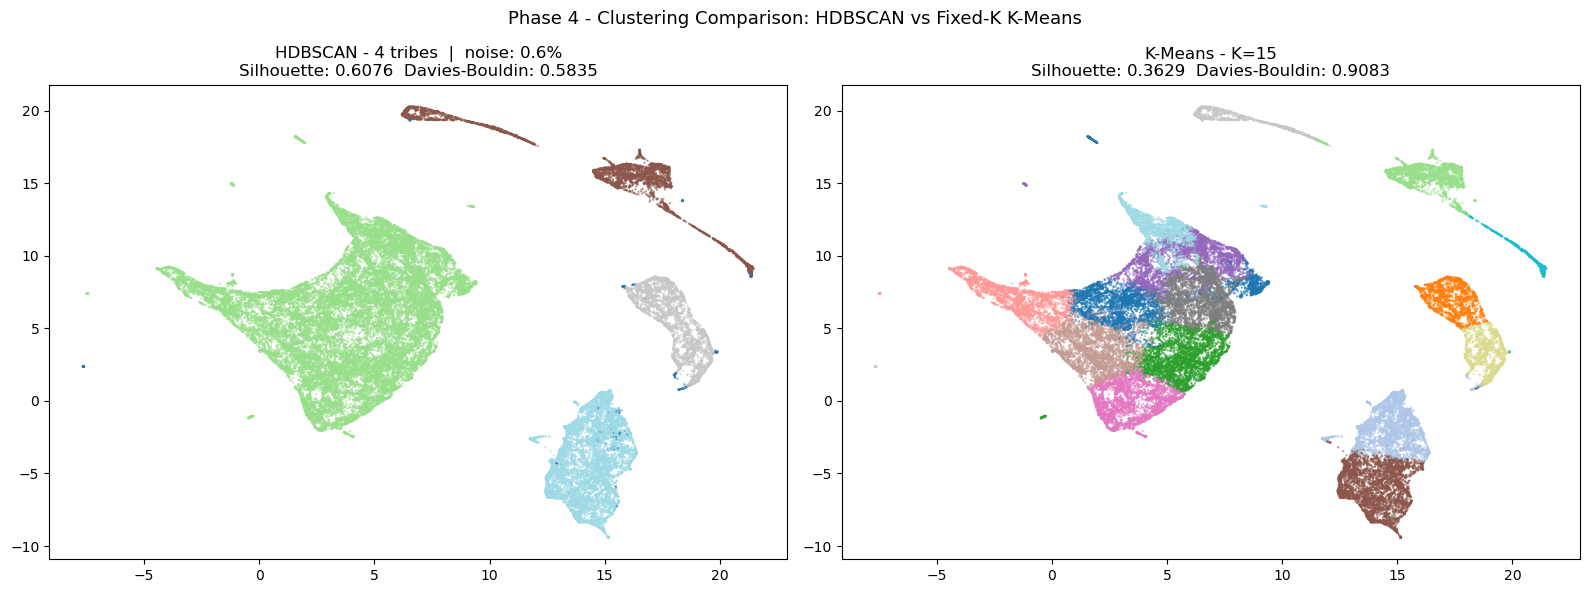

In [22]:
_viz_pd = umap_viz.join(
    hdb_labels.select(["cliente", "cluster"]).rename({"cluster": "tribe_hdbscan"}),
    on="cliente", how="left"
).join(
    km_labels.select(["cliente", "cluster"]).rename({"cluster": "tribe_kmeans"}),
    on="cliente", how="left"
).sample(n=min(100_000, len(umap_viz)), seed=42).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(_viz_pd["x"], _viz_pd["y"],
                c=_viz_pd["tribe_hdbscan"], cmap="tab20", s=0.5, alpha=0.5)
axes[0].set_title(f"HDBSCAN - {n_tribes} tribes  |  noise: {noise_pct:.1f}%\n"
                  f"Silhouette: {results_hdb['silhouette']:.4f}  "
                  f"Davies-Bouldin: {results_hdb['davies_bouldin']:.4f}")

axes[1].scatter(_viz_pd["x"], _viz_pd["y"],
                c=_viz_pd["tribe_kmeans"], cmap="tab20", s=0.5, alpha=0.5)
axes[1].set_title(f"K-Means - K={TARGET_KMEANS_K}\n"
                  f"Silhouette: {results_km['silhouette']:.4f}  "
                  f"Davies-Bouldin: {results_km['davies_bouldin']:.4f}")

plt.suptitle("Phase 4 - Clustering Comparison: HDBSCAN vs Fixed-K K-Means", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "phase4_clustering_comparison.png", dpi=150)
plt.show()

### 3.4.5 How to Read the Clustering Comparison

Use metrics, segment sizes, and commercial profile readability together. Do not select the final segmentation from silhouette alone.